# 8 Contingency in network modelling in PYPSA

To illustrate the mechanics of Security-Constrained Optimal Power Flow (SCOPF), this case study uses a stylized five-bus network specifically designed to expose the dynamics of N-1 security

In [1]:
import pypsa
import pandas as pd

In [2]:
network = pypsa.Network()
network.set_snapshots(pd.date_range("2025-01-01", periods=1, freq="h"))

In [3]:
# Add buses
for i in range(5):
    network.add("Bus", f"Bus {i}", carrier="AC")

In [4]:
# Add generators
network.add("Generator", "G0", bus="Bus 0", p_nom=100, marginal_cost=0, carrier="wind")

network.add("Generator", "G1", bus="Bus 1", p_nom=80, marginal_cost=50, carrier="gas")

network.add("Generator", "G2", bus="Bus 2", p_nom=40, marginal_cost=40, carrier="chp")

network.add(
    "Generator", "G3", bus="Bus 3", p_nom=100, marginal_cost=200, carrier="diesel"
)

In [5]:
# Add loads
network.add("Load", "Load1", bus="Bus 1", p_set=50)

network.add("Load", "Load2", bus="Bus 2", p_set=30)

network.add("Load", "Load3", bus="Bus 3", p_set=40)

network.add("Load", "Load4", bus="Bus 4", p_set=80)

In [6]:
# Add transmission lines (forming a [loop ] plus  a deep spur)
line_params = dict(carrier="AC", x=0.1, r=0.01, s_nom=100)


network.add("Line", "Line_0_1", bus0="Bus 0", bus1="Bus 1", **line_params)

network.add("Line", "Line_1_2", bus0="Bus 1", bus1="Bus 2", **line_params)

network.add("Line", "Line_2_3", bus0="Bus 2", bus1="Bus 3", **line_params)

network.add("Line", "Line_3_0", bus0="Bus 3", bus1="Bus 0", **line_params)

network.add("Line", "Line_1_4", bus0="Bus 1", bus1="Bus 4", **line_params)

A critical modeling device for stress-testing power system reliability is the in­clusion of ``unserved'' generators artificial generators with prohibitively high marginal costs—at every bus in the network. 

These virtual units represent the option of involuntary load shedding: If, during any contingency, the system can­ not deliver sufficient energy to meet demand, these generators are dispatched as
a last resort. Their output directly quantifies unmet demand while the associ­ated costs make clear the economic penalty of failing to maintain N-1 security.

This mechanism mirrors the approach used in the first case study of this chapter,
where a single high-cost generator was added at the main demand bus to account for unserved energy under stress scenarios.

In [7]:
for i in range(5):
    network.add(
        "Generator",
        f"Unserved_{i}",
        bus=f"Bus {i}",
        p_nom=1e4,
        marginal_cost=10_000,
        carrier="unserved",
    )

In [8]:
# solve the baseline OPF
network.optimize(solver_name="highs")
opf_dispatch = network.generators_t.p.copy()
opf_cost = network.objective

# Save baseline model
network.export_to_netcdf("base_network.nc")

/tmp/ipykernel_156465/4036016185.py:2: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name="highs")
Index(['Bus 0', 'Bus 1', 'Bus 2', 'Bus 3', 'Bus 4'], dtype='str', name='name')
Index(['G0', 'G1', 'G2', 'G3', 'Unserved_0', 'Unserved_1', 'Unserved_2',
       'Unserved_3', 'Unserved_4'],
      dtype='str', name='name')
Index(['Line_0_1', 'Line_1_2', 'Line_2_3', 'Line_3_0', 'Line_1_4'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.23s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 14 primals, 34 duals
Objective: 4.60e+03
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-

Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-hfes3985 has 34 rows; 14 cols; 51 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+04]
  Cost    [4e+01, 1e+04]
  Bound   [0e+00, 0e+00]
  RHS     [3e+01, 1e+04]
Presolving model
5 rows, 12 cols, 20 nonzeros 0s
Dependent equations search running on 5 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
5 rows, 12 cols, 20 nonzeros 0s
Presolve reductions: rows 5(-29); columns 12(-2); nonzeros 20(-31) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.0443526255e-03 Pr: 4(11012.5) 0.0s
          5     4.6000000000e+03 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-hfes3985
Model status        : Optimal
Simplex   iterations: 5
Objective value     :  4.60000000

INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'base_network.nc contains: lines, loads, generators, sub_networks, buses


<xarray.Dataset> Size: 2kB
Dimensions:                   (snapshots: 1, lines_i: 5, lines_t_p0_i: 5,
                               lines_t_p1_i: 5, loads_i: 4, loads_t_p_i: 4,
                               generators_i: 9, generators_t_p_i: 3,
                               sub_networks_i: 1, buses_i: 5, buses_t_p_i: 5,
                               buses_t_v_ang_i: 5, buses_t_marginal_price_i: 5)
Coordinates: (12/13)
  * snapshots                 (snapshots) int64 8B 0
  * lines_i                   (lines_i) object 40B 'Line_0_1' ... 'Line_1_4'
  * lines_t_p0_i              (lines_t_p0_i) object 40B 'Line_0_1' ... 'Line_...
  * lines_t_p1_i              (lines_t_p1_i) object 40B 'Line_0_1' ... 'Line_...
  * loads_i                   (loads_i) object 32B 'Load1' 'Load2' ... 'Load4'
  * loads_t_p_i               (loads_t_p_i) object 32B 'Load1' ... 'Load4'
    ...                        ...
  * generators_t_p_i          (generators_t_p_i) object 24B 'G0' 'G1' 'G2'
  * sub_networks_i            (sub_networks_i) object 8B '0'
  * buses_i                   (buses_i) object 40B 'Bus 0' 'Bus 1' ... 'Bus 4'
  * buses_t_p_i               (buses_t_p_i) object 40B 'Bus 0' ... 'Bus 4'
  * buses_t_v_ang_i           (buses_t_v_ang_i) object 40B 'Bus 0' ... 'Bus 4'
  * buses_t_marginal_price_i  (buses_t_marginal_price_i) object 40B 'Bus 0' ....
Data variables: (12/46)
    snapshots_snapshot        (snapshots) datetime64[us] 8B 2025-01-01
    snapshots_objective       (snapshots) float64 8B 1.0
    snapshots_stores          (snapshots) float64 8B 1.0
    snapshots_generators      (snapshots) float64 8B 1.0
    lines_bus0                (lines_i) object 40B 'Bus 0' 'Bus 1' ... 'Bus 1'
    lines_bus1                (lines_i) object 40B 'Bus 1' 'Bus 2' ... 'Bus 4'
    ...                        ...
    buses_control             (buses_i) object 40B 'Slack' 'PQ' 'PQ' 'PQ' 'PQ'
    buses_generator           (buses_i) object 40B 'G0' '' '' '' ''
    buses_sub_network         (buses_i) object 40B '0' '0' '0' '0' '0'
    buses_t_p                 (snapshots, buses_t_p_i) float64 40B 100.0 ... ...
    buses_t_v_ang             (snapshots, buses_t_v_ang_i) float64 40B 5.65 ....
    buses_t_marginal_price    (snapshots, buses_t_marginal_price_i) float64 40B ...
Attributes:
    network__linearized_uc:       0
    network__multi_invest:        0
    network__objective:           4600.0
    network__objective_constant:  0.0
    network_name:                 Unnamed Network
    network_pypsa_version:        1.2.2
    network_srid:                 4326
    crs:                          {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"Wor...
    meta:                         {}

In [9]:
# N-1 security analysis via SCOPF simulation
# Saved baseline network gets imposed with an outage on one transmission line

contingeny_lines = ["Line_0_1", "Line_1_4", "Line_1_2", "Line_2_3", "Line_3_0"]

scopf_dispatches, scopf_costs, scopf_unserved = [], [], []

for line in contingeny_lines:
    m = pypsa.Network("base_network.nc")

    # outing contingency lines
    m.lines.at[line, "s_nom"] = 0

    for bus in m.buses.index:
        if f"Unserved_{bus}" not in m.generators.index:
            m.add(
                "Generator",
                f"Unserved_{bus}",
                bus=bus,
                p_nom=1e4,
                marginal_cost=10_000,
                carrier="unserved",
            )

    status = m.optimize(solver_name="highs")

    if m.objective is None:
        print(f"Infeasible for outage: {line}")
        continue

    scopf_dispatches.append(m.generators_t.p)
    scopf_costs.append(m.objective)

    # Sun unserved generation (load shedding) at this snapshot
    unserved_cols = m.generators_t.p.filter(like="Unserved")
    unserved_sum = unserved_cols.sum(axis=1).values[0]

    scopf_unserved.append(unserved_sum)


if scopf_dispatches:
    # Aggregate the max dispatch across all N-1 contingency cases
    scopf_dispatch = pd.concat(scopf_dispatches).groupby(level=0).max()
else:
    scopf_dispatch = opf_dispatch.copy()

INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.2.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, generators, lines, loads, sub_networks
/tmp/ipykernel_156465/2625900781.py:23: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status = m.optimize(solver_name="highs")
Index(['Bus 0', 'Bus 1', 'Bus 2', 'Bus 3', 'Bus 4'], dtype='str', name='name')
Index(['G0', 'G1', 'G2', 'G3', 'Unserved_0', 'Unserved_1', 'Unserved_2',
       'Unserved_3', 'Unserved_4', 'Unserved_Bus 0', 'Unserved_Bus 1',
       'Unserved_Bus 2', 'Unserved_Bus 3', 'Unserved_Bus 4'],
      dtype='str', name='name')
Index(['Line_0_1', 'Line_1_2', 'Line_2_3', 'Line_3_0', 'Line_1_4'], dtype='str', name='name')
Index(['0'], dtype='str', name='name')
INFO:lin

Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-xpqqlapl has 44 rows; 19 cols; 66 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+04]
  Cost    [4e+01, 1e+04]
  Bound   [0e+00, 0e+00]
  RHS     [3e+01, 1e+04]
Presolving model
6 rows, 13 cols, 20 nonzeros 0s
3 rows, 8 cols, 11 nonzeros 0s
2 rows, 7 cols, 10 nonzeros 0s
1 rows, 6 cols, 5 nonzeros 0s
0 rows, 0 cols, 0 nonzeros 0s
Presolve reductions: rows 0(-44); columns 0(-19); nonzeros 0(-66) - Reduced to empty
Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-xpqqlapl
Model status        : Optimal
Objective value     :  4.6260000000e+05
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00


INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.2.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, generators, lines, loads, sub_networks
/tmp/ipykernel_156465/2625900781.py:23: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status = m.optimize(solver_name="highs")
Index(['Bus 0', 'Bus 1', 'Bus 2', 'Bus 3', 'Bus 4'], dtype='str', name='name')
Index(['G0', 'G1', 'G2', 'G3', 'Unserved_0', 'Unserved_1', 'Unserved_2',
       'Unserved_3', 'Unserved_4', 'Unserved_Bus 0', 'Unserved_Bus 1',
       'Unserved_Bus 2', 'Unserved_Bus 3', 'Unserved_Bus 4'],
      dtype='str', name='name')
Index(['Line_0_1', 'Line_1_2', 'Line_2_3', 'Line_3_0', 'Line_1_4'], dtype='str', name='name')
Index(['0'], dtype='str', name='name')
INFO:lin

Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-05hfsxbh has 44 rows; 19 cols; 66 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+04]
  Cost    [4e+01, 1e+04]
  Bound   [0e+00, 0e+00]
  RHS     [3e+01, 1e+04]
Presolving model
5 rows, 12 cols, 20 nonzeros 0s
Dependent equations search running on 5 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
5 rows, 12 cols, 20 nonzeros 0s
Presolve reductions: rows 5(-39); columns 12(-7); nonzeros 20(-46) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     7.9999999896e+05 Pr: 4(9732.5) 0.0s
          5     8.0080000000e+05 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-05hfsxbh
Model status        : Optimal
Simplex   iterations: 5
Objective value     :  8.008000000

INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.2.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, generators, lines, loads, sub_networks
/tmp/ipykernel_156465/2625900781.py:23: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status = m.optimize(solver_name="highs")
Index(['Bus 0', 'Bus 1', 'Bus 2', 'Bus 3', 'Bus 4'], dtype='str', name='name')
Index(['G0', 'G1', 'G2', 'G3', 'Unserved_0', 'Unserved_1', 'Unserved_2',
       'Unserved_3', 'Unserved_4', 'Unserved_Bus 0', 'Unserved_Bus 1',
       'Unserved_Bus 2', 'Unserved_Bus 3', 'Unserved_Bus 4'],
      dtype='str', name='name')
Index(['Line_0_1', 'Line_1_2', 'Line_2_3', 'Line_3_0', 'Line_1_4'], dtype='str', name='name')
Index(['0'], dtype='str', name='name')
INFO:lin

Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-uo09vju0 has 44 rows; 19 cols; 66 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+04]
  Cost    [4e+01, 1e+04]
  Bound   [0e+00, 0e+00]
  RHS     [3e+01, 1e+04]
Presolving model
6 rows, 13 cols, 20 nonzeros 0s
Dependent equations search running on 5 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
5 rows, 11 cols, 17 nonzeros 0s
Presolve reductions: rows 5(-39); columns 11(-8); nonzeros 17(-49) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -7.3340367178e-04 Pr: 4(9059.38) 0.0s
          5     4.7666666667e+03 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-uo09vju0
Model status        : Optimal
Simplex   iterations: 5
Objective value     :  4.76666666

INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.2.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, generators, lines, loads, sub_networks
/tmp/ipykernel_156465/2625900781.py:23: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status = m.optimize(solver_name="highs")
Index(['Bus 0', 'Bus 1', 'Bus 2', 'Bus 3', 'Bus 4'], dtype='str', name='name')
Index(['G0', 'G1', 'G2', 'G3', 'Unserved_0', 'Unserved_1', 'Unserved_2',
       'Unserved_3', 'Unserved_4', 'Unserved_Bus 0', 'Unserved_Bus 1',
       'Unserved_Bus 2', 'Unserved_Bus 3', 'Unserved_Bus 4'],
      dtype='str', name='name')
Index(['Line_0_1', 'Line_1_2', 'Line_2_3', 'Line_3_0', 'Line_1_4'], dtype='str', name='name')
Index(['0'], dtype='str', name='name')
INFO:lin

Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-rvmx9j40 has 44 rows; 19 cols; 66 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+04]
  Cost    [4e+01, 1e+04]
  Bound   [0e+00, 0e+00]
  RHS     [3e+01, 1e+04]
Presolving model
6 rows, 13 cols, 20 nonzeros 0s
4 rows, 10 cols, 16 nonzeros 0s
Dependent equations search running on 4 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
4 rows, 10 cols, 16 nonzeros 0s
Presolve reductions: rows 4(-40); columns 10(-9); nonzeros 16(-50) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -4.3001308123e-04 Pr: 4(8565) 0.0s
          4     5.1000000000e+03 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-rvmx9j40
Model status        : Optimal
Simplex   iterations: 4
Obje

INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.2.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, generators, lines, loads, sub_networks
/tmp/ipykernel_156465/2625900781.py:23: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status = m.optimize(solver_name="highs")
Index(['Bus 0', 'Bus 1', 'Bus 2', 'Bus 3', 'Bus 4'], dtype='str', name='name')
Index(['G0', 'G1', 'G2', 'G3', 'Unserved_0', 'Unserved_1', 'Unserved_2',
       'Unserved_3', 'Unserved_4', 'Unserved_Bus 0', 'Unserved_Bus 1',
       'Unserved_Bus 2', 'Unserved_Bus 3', 'Unserved_Bus 4'],
      dtype='str', name='name')
Index(['Line_0_1', 'Line_1_2', 'Line_2_3', 'Line_3_0', 'Line_1_4'], dtype='str', name='name')
Index(['0'], dtype='str', name='name')
INFO:lin

Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-hhk1ws0j has 44 rows; 19 cols; 66 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+04]
  Cost    [4e+01, 1e+04]
  Bound   [0e+00, 0e+00]
  RHS     [3e+01, 1e+04]
Presolving model
6 rows, 13 cols, 20 nonzeros 0s
Dependent equations search running on 4 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
4 rows, 9 cols, 14 nonzeros 0s
Presolve reductions: rows 4(-40); columns 9(-10); nonzeros 14(-52) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -4.6284008144e-04 Pr: 4(9026.25) 0.0s
          4     1.5600000000e+04 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-hhk1ws0j
Model status        : Optimal
Simplex   iterations: 4
Objective value     :  1.560000000

In [ ]:
opf_dispatch["type"] = "Base OPF"
scopf_dispatch["type"] = "Strict SCOPF"

opf_dispatch.columns = opf_dispatch.columns.astype(str)

scopf_dispatch.columns = scopf_dispatch.columns.astype(str)

dispatch_all = pd.concat([opf_dispatch, scopf_dispatch])
dispatch_all = dispatch_all.reset_index().melt(
    id_vars=["snapshot", "type"], var_name="Generator", value_name="Dispatch"
)

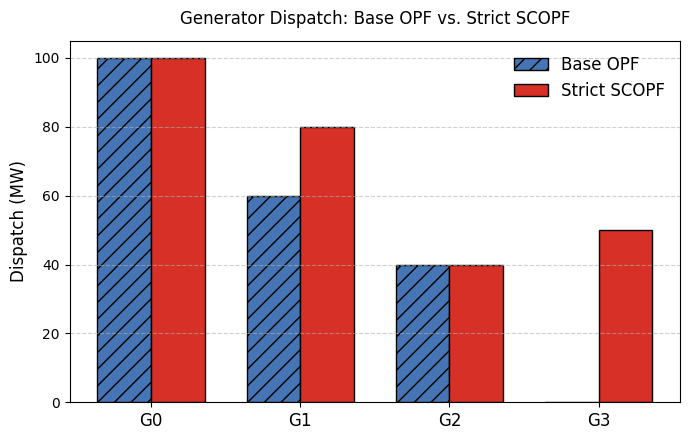

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4.5))
generators = ["G0", "G1", "G2", "G3"]
colors = {"Base OPF": "#4575b4", "Strict SCOPF": "#d73027"}
hatch = {"Base OPF": "//", "Strict SCOPF": ""}

for i, gen in enumerate(generators):
    for mode in ["Base OPF", "Strict SCOPF"]:
        val = dispatch_all[
            (dispatch_all["Generator"] == gen) & (dispatch_all["type"] == mode)
        ]["Dispatch"].values[0]

        offset = -0.18 if mode == "Base OPF" else 0.18
        plt.bar(
            i + offset,
            val,
            width=0.36,
            color=colors[mode],
            hatch=hatch[mode],
            edgecolor="k",
            label=mode if i == 0 else "",
        )


plt.xticks(range(len(generators)), generators, fontsize=12)
plt.ylabel("Dispatch (MW)", fontsize=12)
plt.title("Generator Dispatch: Base OPF vs. Strict SCOPF", fontsize=12, pad=12)
plt.legend(fontsize=12, frameon=False)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [15]:
import numpy as np

In [16]:
print("Base OPF cost:", round(opf_cost, 2))
print("Average SCOPF contingency cost:", round(np.mean(scopf_costs), 2))
print("Worst-case SCOPF contingency cost:", round(np.max(scopf_costs), 2))
# Average unserved energy (MW) in SCOPF cases
if scopf_unserved:
    avg_unserved = np.mean(scopf_unserved)
else:
    avg_unserved = 0
    print("Average unserved energy in SCOPF cases:", avg_unserved)
# Max unserved energy (MW) in SCOPF cases
if scopf_unserved:
    max_unserved = np.max(scopf_unserved)
else:
    max_unserved = 0
    print("Max unserved energy in SCOPF cases:", max_unserved)

Base OPF cost: 4600.0
Average SCOPF contingency cost: 257773.33
Worst-case SCOPF contingency cost: 800800.0


These findings make it clear that SCOPF is not merely a more rigorous optimization, but a practical lens for exposing structural vulnerabilities. By em­bedding security constraints into the dispatch, SCOPF forces the network to reveal where its weak points lie-whether through reliance on specific corri­dors, over-dependence on certain generators, or insufficient capacity to absorb
shocks. 

The requirement to maintain feasibility under all considered contingen­cies compels the system to hold back cheap wind or CHP in favor of more robust but costly reserves, fundamentally altering both the dispatch and the economics
of operation.
